In [68]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [69]:
import numpy as np
import pandas as pd
import nltk
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
from nltk.util import ngrams
import matplotlib.pyplot as plt

In [70]:
path = '/content/drive/MyDrive/Colab Notebooks/Parent.xlsx'
df = pd.read_excel(path)

In [71]:
import re

# Define a dictionary to map current column names to new, shorter names
new_column_names = {
    '1. Are you aware that your child uses AI tools?\n자녀가 AI 도구를 사용하는 것을 알고 계신가요?': 'AI_Awareness',
    '2. Do you think AI helps your child\'s learning?\nAI가 자녀의 학습에 도움이 된다고 생각하시나요?': 'AI_Learning_Help',
    '3. Do you think AI has a positive impact on your child\'s thinking development?\nAI가 자녀의 사고력 발달에 긍정적인 영향을 준다고 생각하시나요?': 'AI_Thinking_Impact',
    '4. Do you think AI can improve your child\'s creativity?\nAI가 자녀의 창의성을 높일 수 있다고 생각하시나요?': 'AI_Creativity',
    '5. Does AI help increase your child\'s motivation to learn?\nAI가 자녀의 학습 동기를 높이는 데 도움이 된다고 생각하시나요?': 'AI_Motivation',
    '6. Can AI replace teachers\' roles?\nAI가 교사의 역할을 대체할 수 있다고 생각하시나요?': 'AI_Replace_Teachers',
    '7. What worries you most about your child using AI?\nAI 사용 시 가장 걱정되는 점은 무엇인가요?': 'AI_Worries',
    '8. Do you support expanding AI education in schools?\n학교에서 AI 교육을 확대하는 것에 찬성하시나요?': 'AI_Education_expand',
    '9. What new educational direction do you think is needed in the AI era ?\nAI 시대에 필요한 새로운 교육 방향은 무엇이라고 생각하시나요?': 'AI_education',
    '10. What you think is the most important aspect of AI education?\nAI 교육에서 가장 중요한 것은 무엇이라고 생각하시나요?' : 'Important_education'
}

# Rename the columns using the mapping
df = df.rename(columns=new_column_names)

# Function to clean string values by removing text after '/'
def clean_string_values(df):
    for column in df.columns:
        if df[column].dtype == 'object':  # Check if the column contains string data
            df[column] = df[column].astype(str).apply(lambda x: re.split(' / ', x)[0].strip() if ' / ' in x else x)
    return df

# Apply the cleaning function to the DataFrame
df = clean_string_values(df)

# Display the first few rows with the cleaned values
display(df.head())

,time,AI_Awareness,AI_Learning_Help,AI_Thinking_Impact,AI_Creativity,AI_Motivation,AI_Replace_Teachers,AI_Worries,AI_Education_expand,AI_education,Important_education
0,2025-10-26 21:47:46.045,Sometimes,Agree,Agree,Agree,Agree,Full replaceable,Learning false info,Agree,Self driven learning,Accurate learning information and security.
1,2025-10-26 22:01:22.922,Not at all,Neutral,Strongly disagree,Strongly disagree,Strongly agree,Partly supportive,Over reliance on AI,Disagree,Research on new academic fields or advice on l...,I believe AI should assist in activities that ...
2,2025-10-26 22:04:20.843,Sometimes,Neutral,Neutral,Disagree,Agree,Hardly possible,Learning false info,Disagree,"While AI may be able to replace knowledge, I b...",Humanity and ethics
3,2025-10-26 22:09:20.361,Sometimes,Neutral,Neutral,Disagree,Neutral,Partly supportive,Over reliance on AI,Agree,The standardized numerical part can be accurat...,The direction of human education remains uncha...
4,2025-10-26 22:09:35.545,Sometimes,Neutral,Neutral,Disagree,Disagree,Full replaceable,Over reliance on AI,Agree,Education should focus on using AI to develop ...,I believe it is important to use AI to broaden...


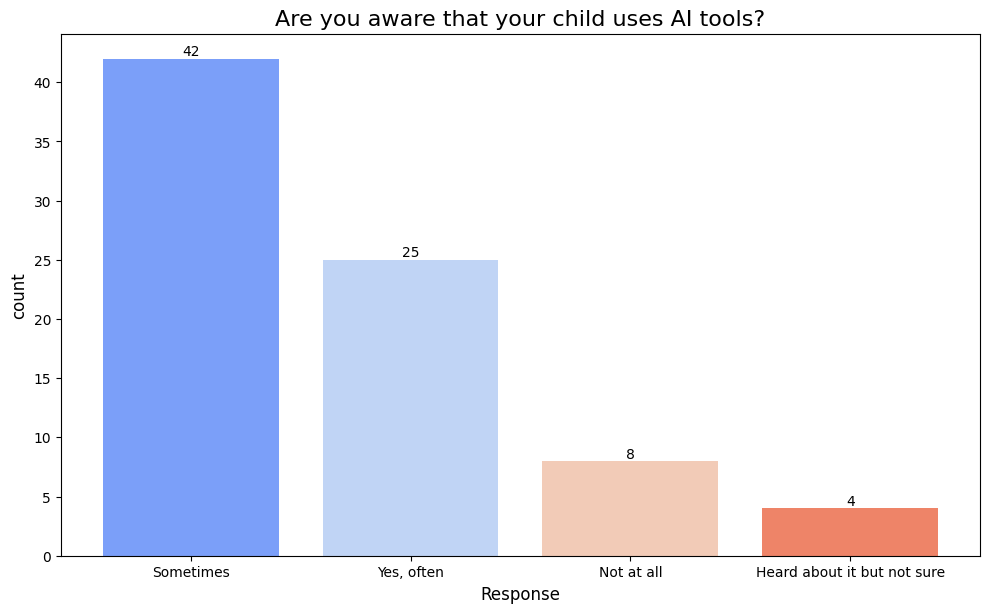

In [72]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts and sort them in descending order
awareness_counts = df['AI_Awareness'].value_counts().sort_values(ascending=False)

# Create a bar plot using matplotlib with improved aesthetics
plt.figure(figsize=(10, 6)) # Set a good figure size
plt.bar(awareness_counts.index, awareness_counts.values, color=sns.color_palette("coolwarm", len(awareness_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Are you aware that your child uses AI tools?", fontsize=16)
plt.ylabel("count", fontsize=12)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.xlabel("Response", fontsize=12)
plt.show()

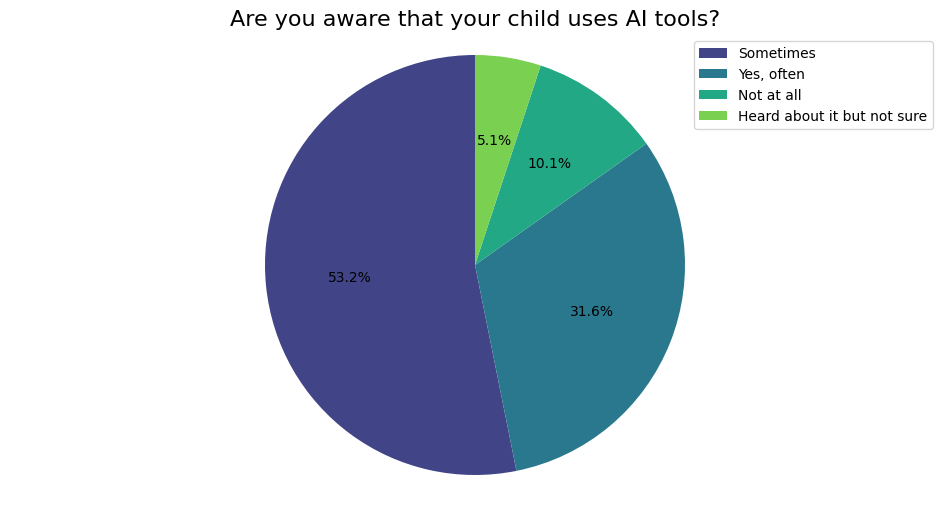

In [73]:
# with pie chart
plt.figure(figsize=(12, 6))
plt.pie(awareness_counts.values, colors=sns.color_palette("viridis", len(awareness_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Are you aware that your child uses AI tools?", fontsize=16)
plt.axis('equal')
plt.legend(labels=awareness_counts.index, loc='upper right')
plt.show()

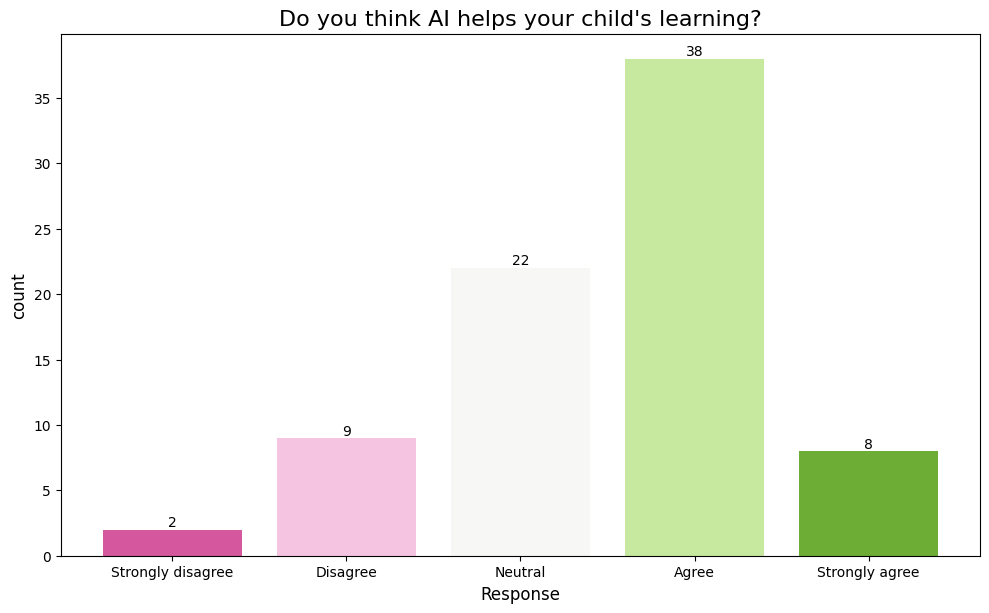

In [74]:
# Calculate the value counts
help_counts = df['AI_Learning_Help'].value_counts()

# Define a custom order for the categories
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order
help_counts = help_counts.reindex(custom_order, fill_value=1)

# Create a bar plot using matplotlib with improved aesthetics
plt.figure(figsize=(10, 6)) # Set a good figure size
plt.bar(help_counts.index, help_counts.values, color=sns.color_palette("PiYG", len(help_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you think AI helps your child's learning?", fontsize=16)
plt.ylabel("count", fontsize=12)
plt.tight_layout()
plt.xlabel("Response", fontsize=12)
plt.show()

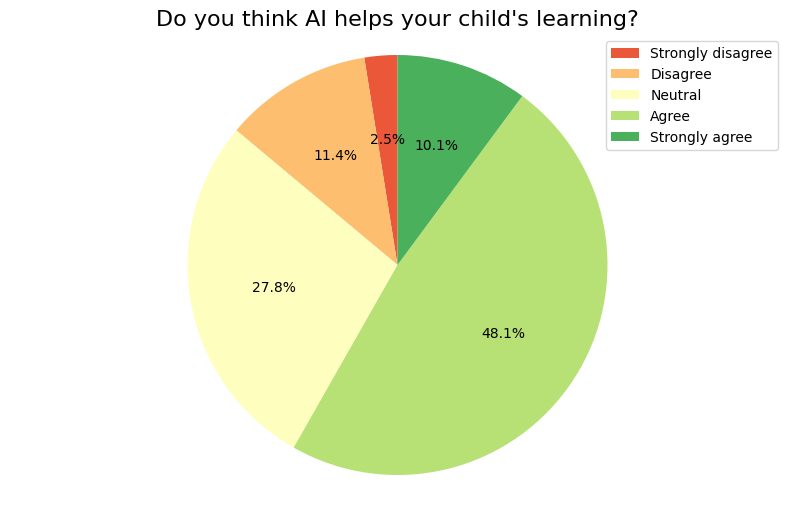

In [75]:
# question 2 pie chart
plt.figure(figsize=(10, 6))
plt.pie(help_counts.values, colors=sns.color_palette("RdYlGn", len(help_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think AI helps your child's learning?", fontsize=16)
plt.legend(labels=help_counts.index, loc='upper right')
plt.axis('equal')
plt.show()

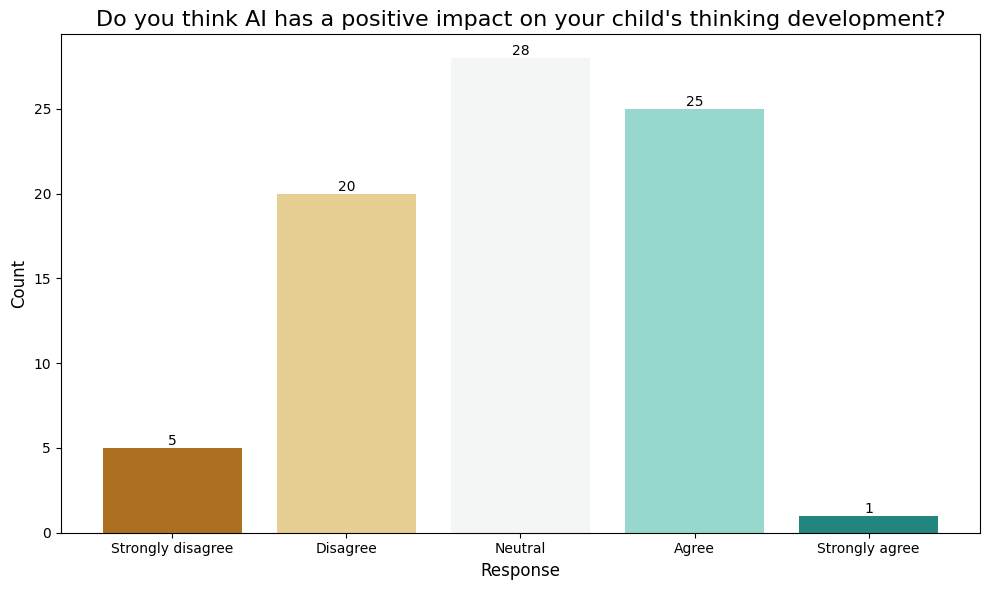

In [76]:
# Question 3
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Thinking_Impact
thinking_impact_counts = df['AI_Thinking_Impact'].value_counts()

# Define a custom order for the categories (same as previous questions with Likert scale)
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
thinking_impact_counts = thinking_impact_counts.reindex(custom_order, fill_value=0)

# Create a bar plot for AI_Thinking_Impact
plt.figure(figsize=(10, 6))
plt.bar(thinking_impact_counts.index, thinking_impact_counts.values, color=sns.color_palette("BrBG", len(thinking_impact_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you think AI has a positive impact on your child's thinking development?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

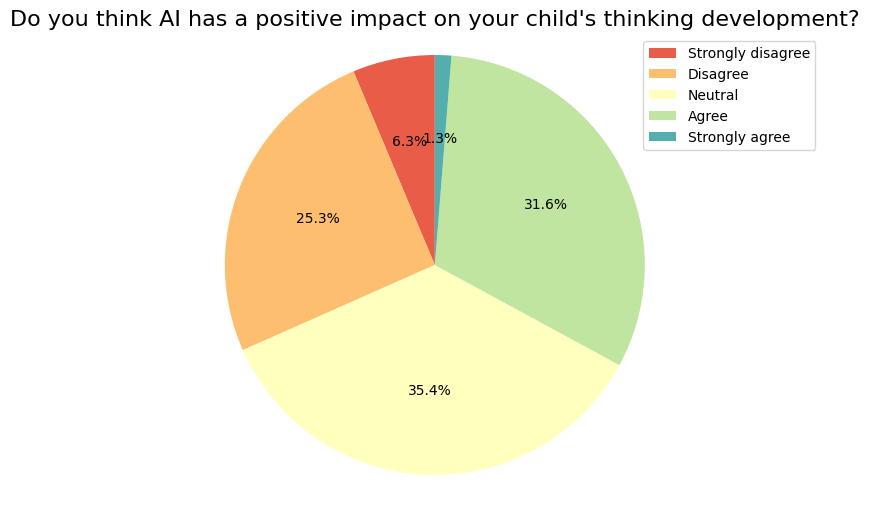

In [77]:
# Create a pie chart for AI_Thinking_Impact
plt.figure(figsize=(10, 6))
plt.pie(thinking_impact_counts.values, colors=sns.color_palette("Spectral", len(thinking_impact_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think AI has a positive impact on your child's thinking development?", fontsize=16)
plt.legend(labels=thinking_impact_counts.index, loc='upper right')
plt.axis('equal')
plt.show()

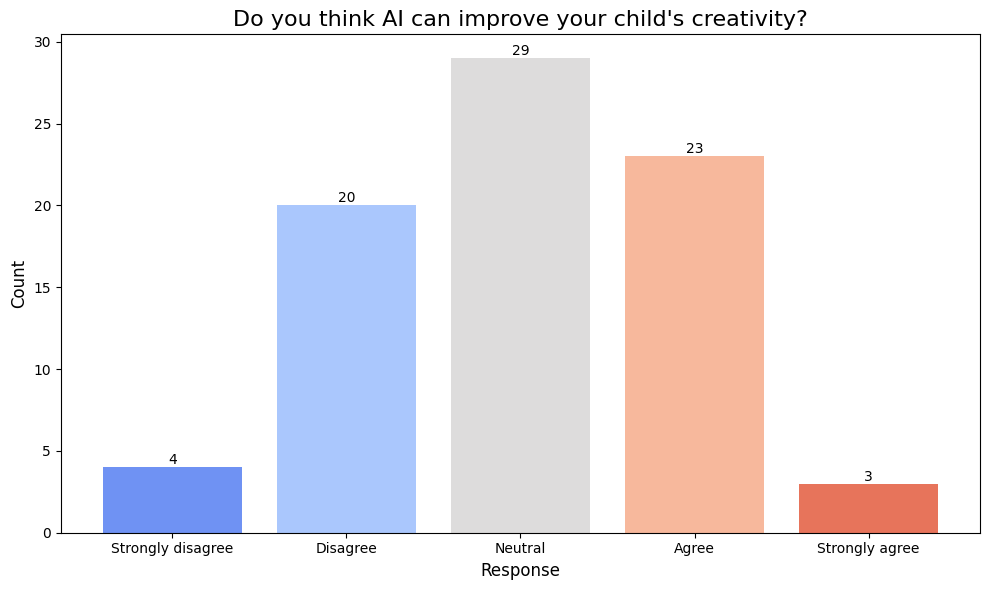

In [78]:
# question 4
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Creativity
creativity_counts = df['AI_Creativity'].value_counts()

# Define a custom order for the categories (Likert scale)
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
creativity_counts = creativity_counts.reindex(custom_order, fill_value=0)

# Create a bar plot for AI_Creativity
plt.figure(figsize=(10, 6))
plt.bar(creativity_counts.index, creativity_counts.values, color=sns.color_palette("coolwarm", len(creativity_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you think AI can improve your child's creativity?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

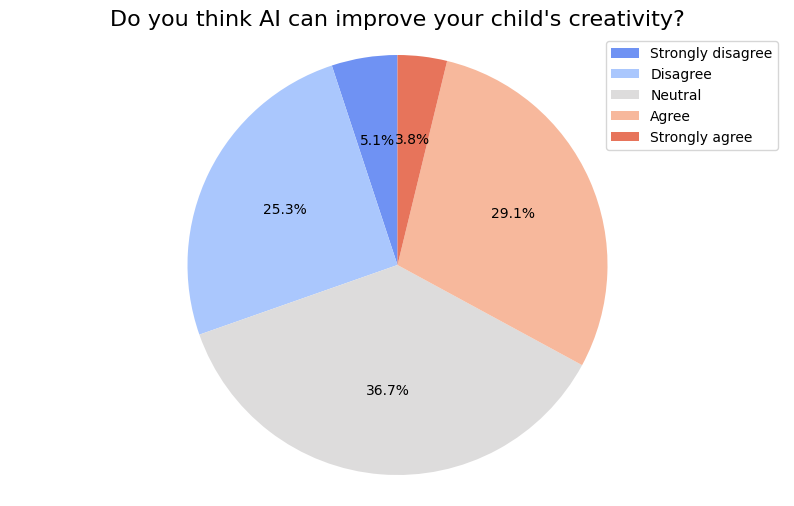

In [79]:
# Create a pie chart for AI_Creativity
plt.figure(figsize=(10, 6))
plt.pie(creativity_counts.values, colors=sns.color_palette("coolwarm", len(creativity_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Do you think AI can improve your child's creativity?", fontsize=16)
plt.legend(labels=creativity_counts.index, loc='upper right')
plt.axis('equal')
plt.show()

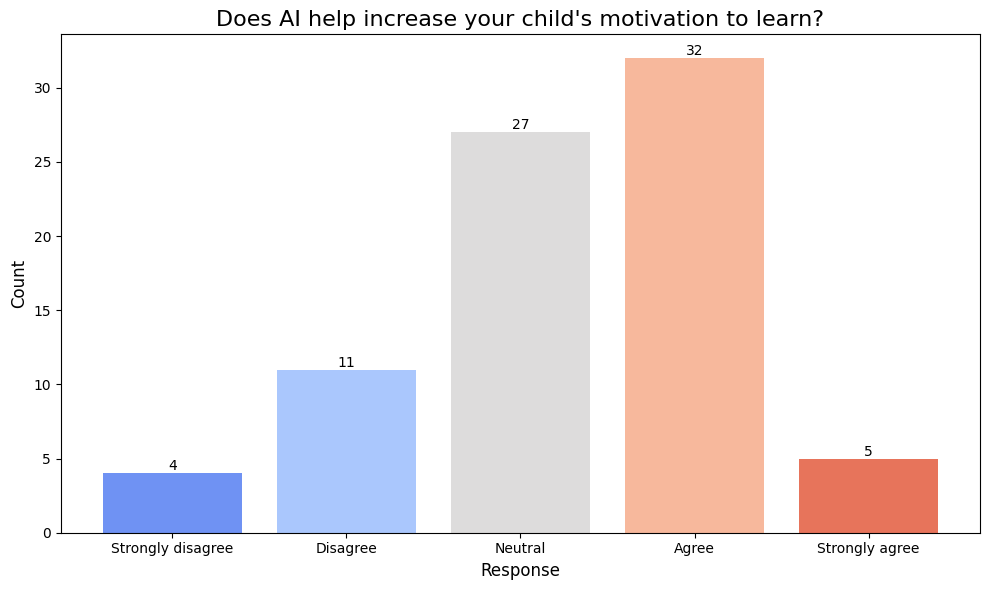

In [80]:
# Question 5
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Motivation
motivation_counts = df['AI_Motivation'].value_counts()

# Define a custom order for the categories (Likert scale)
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
motivation_counts = motivation_counts.reindex(custom_order, fill_value=0)

# Create a bar plot for AI_Motivation
plt.figure(figsize=(10, 6))
plt.bar(motivation_counts.index, motivation_counts.values, color=sns.color_palette("coolwarm", len(motivation_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Does AI help increase your child's motivation to learn?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

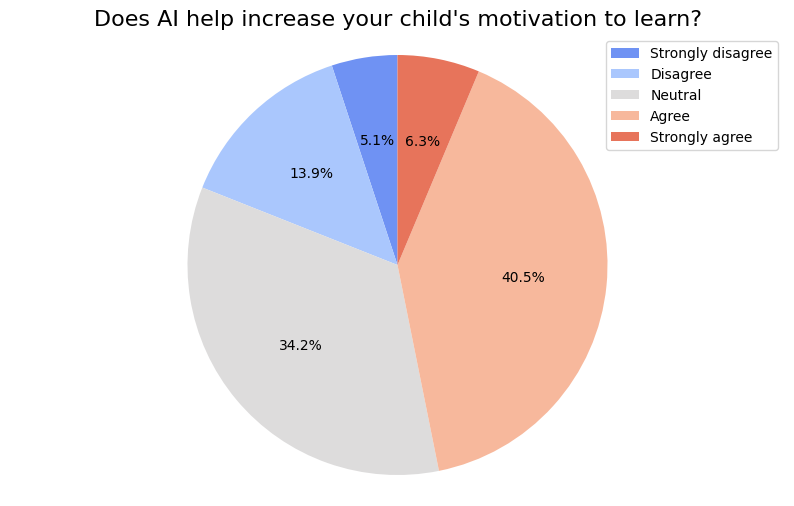

In [81]:
# Create a pie chart for AI_Motivation
plt.figure(figsize=(10, 6))
plt.pie(motivation_counts.values, colors=sns.color_palette("coolwarm", len(motivation_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Does AI help increase your child's motivation to learn?", fontsize=16)
plt.legend(labels=motivation_counts.index, loc='upper right')
plt.axis('equal')
plt.show()

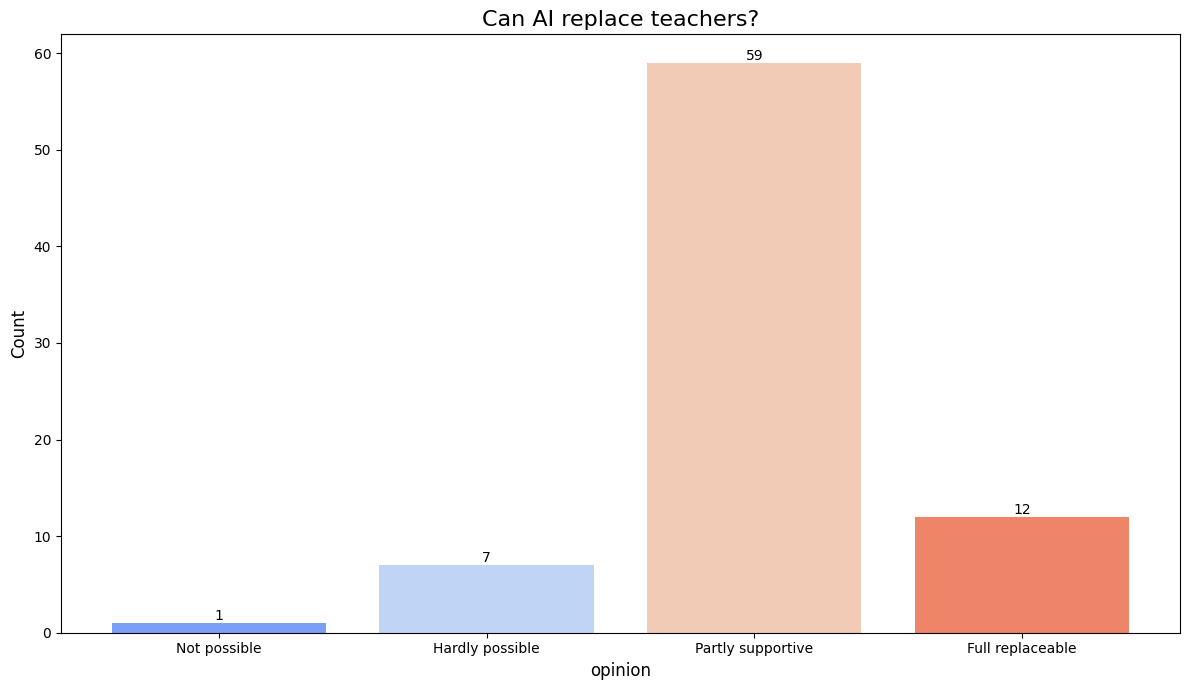

In [82]:
# Question 6
import matplotlib.pyplot as plt
import seaborn as sns

replace = df['AI_Replace_Teachers'].value_counts()

custom_order = ['Not possible', 'Hardly possible', 'Partly supportive', 'Full replaceable']

replace_count = replace.reindex(custom_order, fill_value=0)

plt.figure(figsize=(12, 7))
plt.bar(replace_count.index, replace_count.values, color=sns.color_palette("coolwarm", len(replace_count)))

plt.bar_label(plt.gca().containers[0])

plt.title("Can AI replace teachers?", fontsize=16)
plt.xlabel("opinion", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

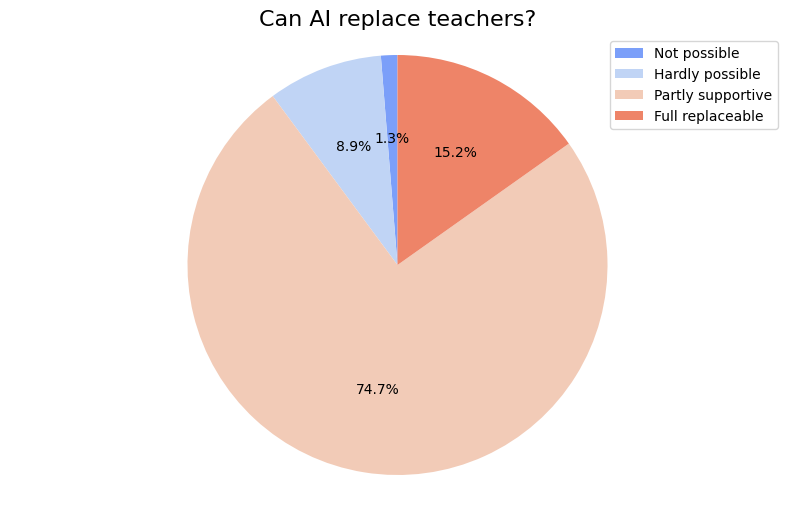

In [83]:
# Pie chart for Question 6
plt.figure(figsize=(10, 6))
plt.pie(replace_count.values, colors=sns.color_palette("coolwarm", len(replace_count)), autopct='%1.1f%%', startangle=90)
plt.title("Can AI replace teachers?", fontsize=16)
plt.legend(labels=replace_count.index, loc='upper right')
plt.axis('equal')
plt.show()

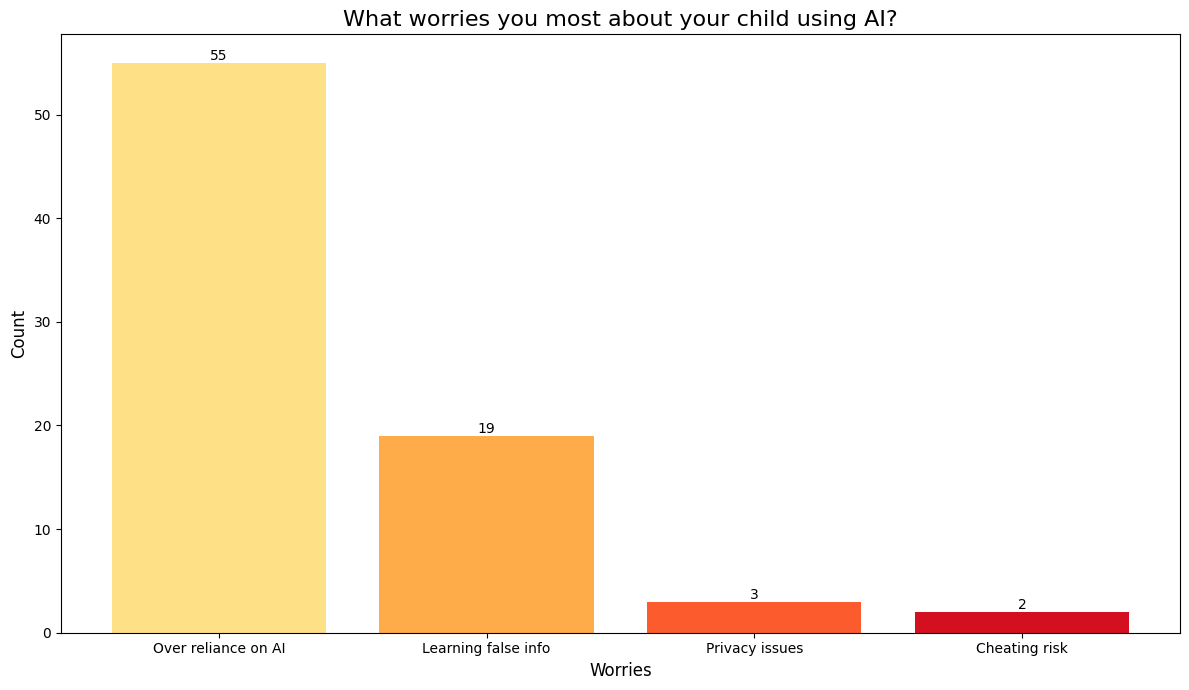

In [84]:
# Question 7
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Worries
worries_counts = df['AI_Worries'].value_counts()

# There isn't a standard Likert scale for 'worries', so we'll just sort by value for the bar chart
worries_counts = worries_counts.sort_values(ascending=False)

# Create a bar plot for AI_Worries
plt.figure(figsize=(12, 7))
plt.bar(worries_counts.index, worries_counts.values, color=sns.color_palette("YlOrRd", len(worries_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("What worries you most about your child using AI?", fontsize=16)
plt.xlabel("Worries", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

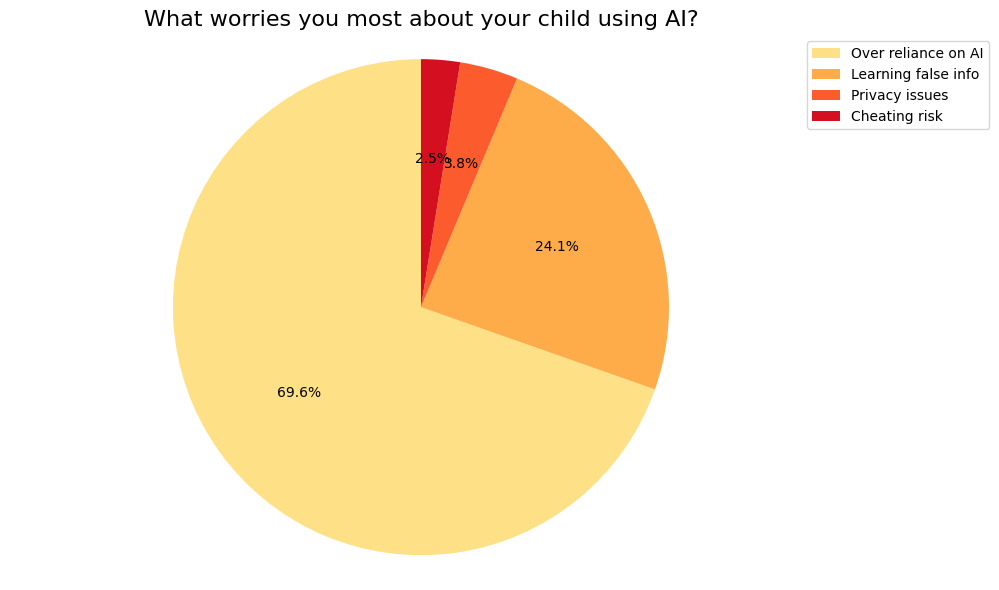

In [85]:
# Create a pie chart for AI_Worries
plt.figure(figsize=(10, 6))
plt.pie(worries_counts.values, colors=sns.color_palette("YlOrRd", len(worries_counts)), autopct='%1.1f%%', startangle=90)
plt.title("What worries you most about your child using AI?", fontsize=16)
plt.legend(labels=worries_counts.index, loc='upper right', bbox_to_anchor=(1.2, 1)) # Adjust legend position to avoid overlapping
plt.axis('equal')
plt.tight_layout()
plt.show()

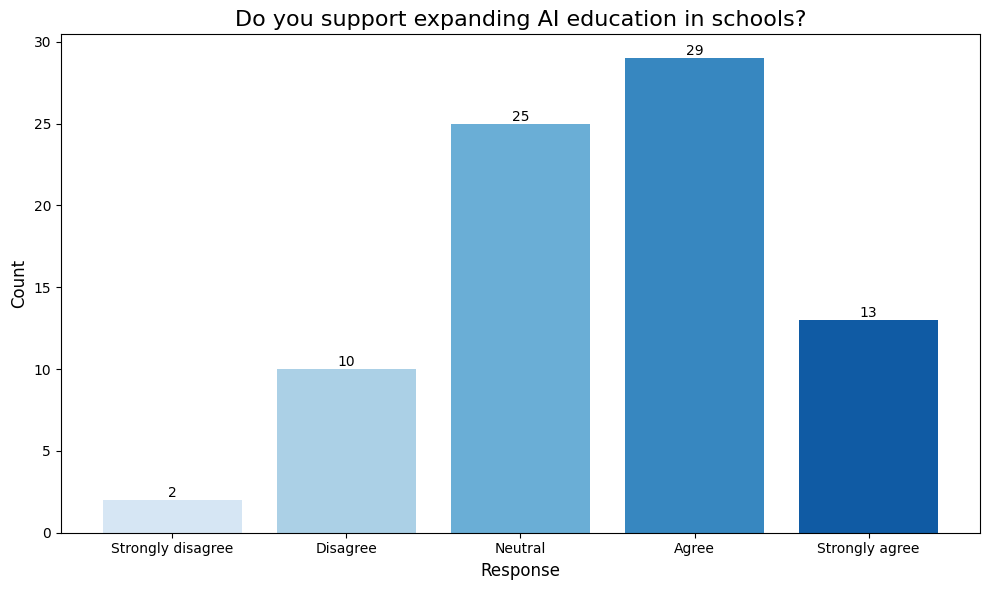

In [86]:
# Question 8
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the value counts for AI_Education_expand
education_expand_counts = df['AI_Education_expand'].value_counts()

# Define a custom order for the categories (Likert scale)
custom_order = ['Strongly disagree', 'Disagree', 'Neutral', 'Agree', 'Strongly agree']

# Reindex the series to apply the custom order, filling missing categories with 0
education_expand_counts = education_expand_counts.reindex(custom_order, fill_value=0)

# Create a bar plot for AI_Education_expand
plt.figure(figsize=(10, 6))
plt.bar(education_expand_counts.index, education_expand_counts.values, color=sns.color_palette("Blues", len(education_expand_counts)))

# Add labels to the bars
plt.bar_label(plt.gca().containers[0])

plt.title("Do you support expanding AI education in schools?", fontsize=16)
plt.xlabel("Response", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.tight_layout()
plt.show()

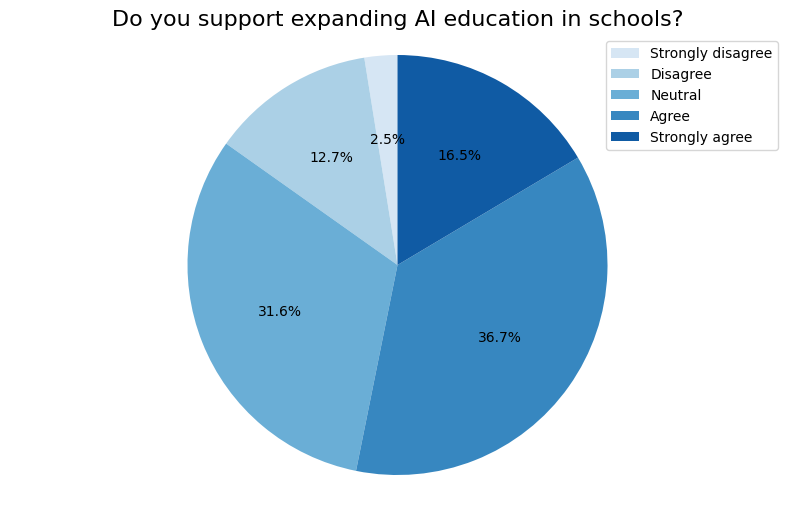

In [87]:
# Create a pie chart for AI_Education_expand
plt.figure(figsize=(10, 6))
plt.pie(education_expand_counts.values, colors=sns.color_palette("Blues", len(education_expand_counts)), autopct='%1.1f%%', startangle=90)
plt.title("Do you support expanding AI education in schools?", fontsize=16)
plt.legend(labels=education_expand_counts.index, loc='upper right')
plt.axis('equal')
plt.show()

In [88]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
nltk.download('wordnet')

custom_word = {
    ',', '.', 'the', 'and', 'this', 'that', 'from', 'your', 'will', 'you',
    'for', 'its', 'their', 'here', 'there', 'when', 'while', '’', 's', '’s',
    'throughout', 'around', 'into', 'onto', 'upon', 'about', 'above', 'below',
    'shall', 'should', 'would', 'is', 'are', 'was', 'were', 'be',
    'an', 'a', 'of', 'to', 'in', 'on', 'at', 'by', 'or', "listings", "*"
}

nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [89]:
# Question 9 Processing

df['AI_education'] = df['AI_education'].fillna('')
df['AI_education'] = df[(df['AI_education'] != ".") & (df['AI_education'] != "-")]['AI_education']

lemmatizer = WordNetLemmatizer()

processed_education_texts = []

for text_entry in df['AI_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    processed_text = ' '.join(filtered_and_lemmatized_tokens)

    processed_education_texts.append(processed_text)

print(processed_education_texts)

['self driven learning', 'research new academic field advice learning process would helpful', 'ai may able replace knowledge believe human value humanity taught people', 'standardized numerical part accurate ai thought thinking part done human educating importance correct thinking', 'education focus using ai develop curriculum learning method rather simply using ai find answer', 'regulation illegal information', 'since world living without ai difficult soon arrive ai ignored need incorporated learning process extent however believe clear strict distinction student understanding ai using assignment', 'learning tailored individual level understanding rather focusing standardized approach', 'curriculum', 'literacy questioning skill', 'believe ai serve support tool may still early ai take leading role education', 'unavoidable ai active utilization education', 'limiting dependence ai function selective utilization', 'need education expands interpersonal interaction', 'cultivating communicat

In [90]:
# Question 10 Processing
df['Important_education'] = df['Important_education'].fillna('')
df['Important_education'] = df[(df['Important_education'] != ".") & (df['Important_education'] != "-")]['Important_education']

lemmatizer = WordNetLemmatizer()

processed_important_education_texts = []

for text_entry in df['Important_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    processed_text = ' '.join(filtered_and_lemmatized_tokens)

    processed_important_education_texts.append(processed_text)

print(processed_important_education_texts)

['accurate learning information security', 'believe ai assist activity focus exploring process rather simply finding answer', 'humanity ethic', 'direction human education remains unchanged ai major tool improving education modern society necessary consult discus direction improvement member society', 'believe important use ai broaden scope thinking providing information rather letting ai think behalf', 'accurate information', 'important clearly recognize limitation potential problem ai ai perfect provide incorrect misleading information particular student become overly dependent ai completing assignment may hinder development critical thinking creativity therefore educational guidance take concern account necessary', 'creativity originality', 'literacy creativity independent thinking skill', 'reading education support learning develop interpretation analysis application skill', 'accuracy information', 'creativity', 'using ai tool refine supplement one work opinion', 'education foster c

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


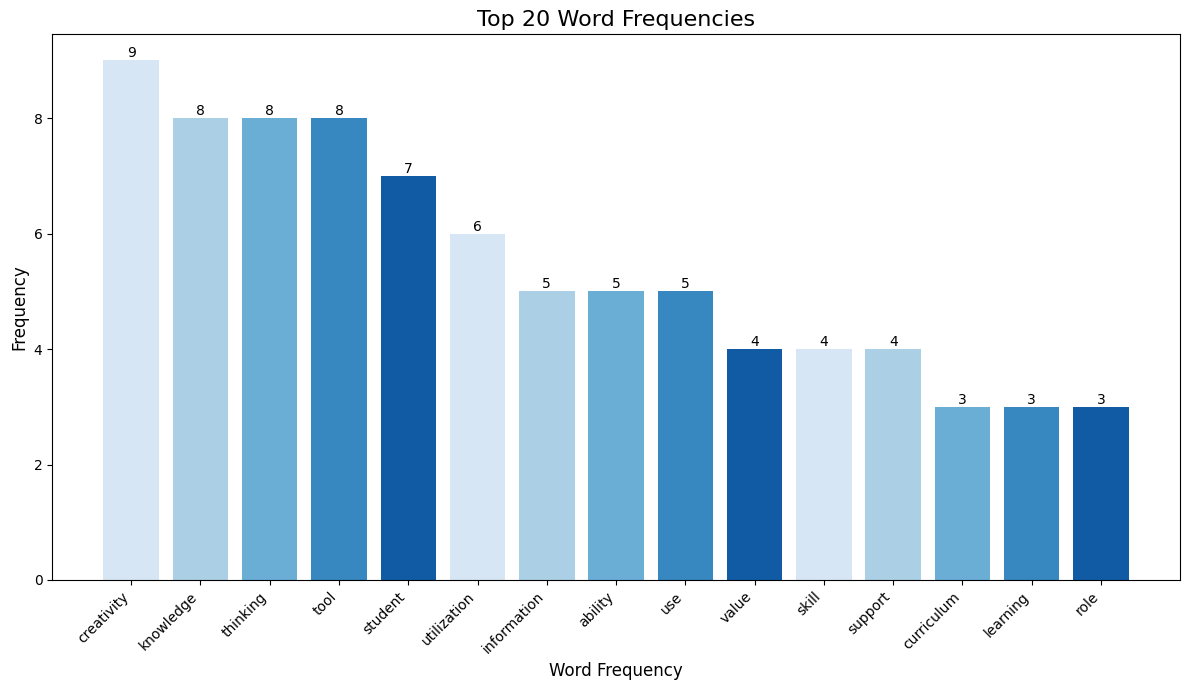

In [91]:
nltk.download('averaged_perceptron_tagger_eng')

# Question 9 Word Frequency (no meaning in bigram)

tagged_education_texts = []
for text in processed_education_texts:
  if text.strip():
    tagged_education_texts.append(nltk.pos_tag(nltk.word_tokenize(text)))

noun_data = []
for tagged_text in tagged_education_texts:
    exclude_words = ["ai", "education"]
    nouns = [
        word.lower() for word, tag in tagged_text
        if tag.startswith('N') and word.lower() not in exclude_words
    ]
    noun_data.extend(nouns)

noun_counts = Counter(noun_data)

noun_counts = noun_counts.most_common(15)

plt.figure(figsize=(12, 7))
plt.bar([bigram for bigram, count in noun_counts], [count for bigram, count in noun_counts], color=sns.color_palette("Blues", len(education_expand_counts)))
plt.xlabel("Word Frequency", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.bar_label(plt.gca().containers[0])
plt.title("Top 20 Word Frequencies", fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

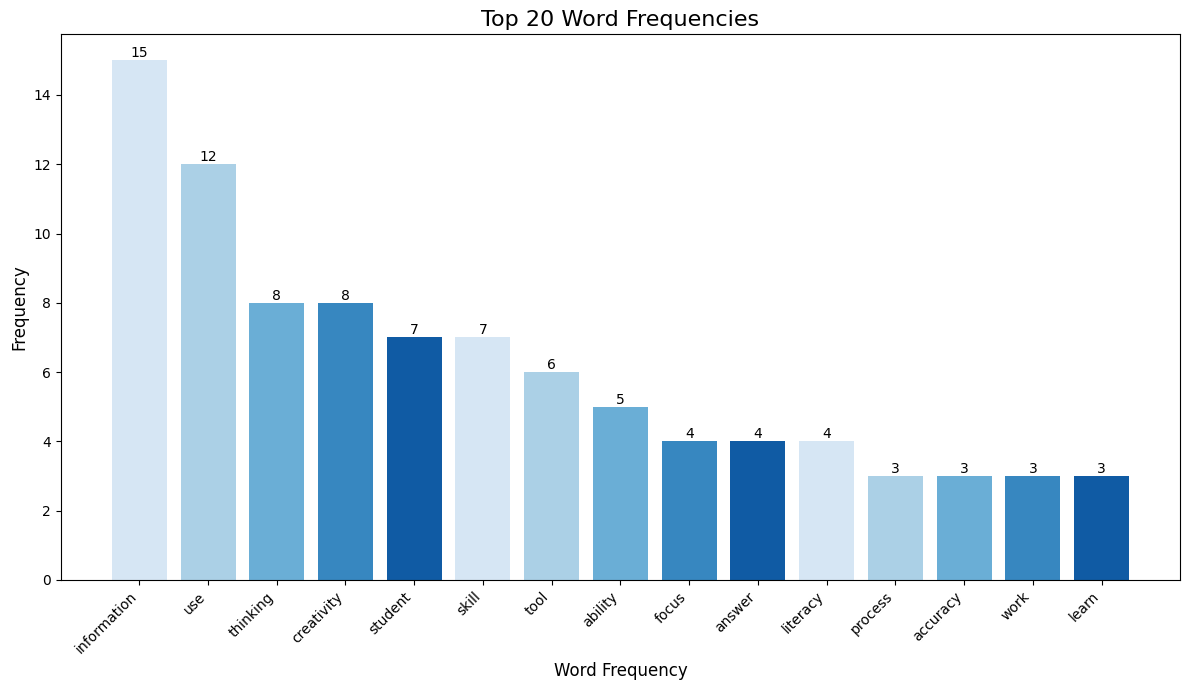

In [92]:
# Question 10 Word Frequency

tagged_important_education_texts = []
for text in processed_important_education_texts:
  if text.strip():
    tagged_important_education_texts.append(nltk.pos_tag(nltk.word_tokenize(text)))

noun_data = []
for tagged_text in tagged_important_education_texts:
    exclude_words = ["ai", "education"]
    nouns = [
        word.lower() for word, tag in tagged_text
        if tag.startswith('N') and word.lower() not in exclude_words
    ]
    noun_data.extend(nouns)

noun_counts = Counter(noun_data)

noun_counts = noun_counts.most_common(15)

plt.figure(figsize=(12, 7))
plt.bar([bigram for bigram, count in noun_counts], [count for bigram, count in noun_counts], color=sns.color_palette("Blues", len(education_expand_counts)))
plt.xlabel("Word Frequency", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.bar_label(plt.gca().containers[0])
plt.title("Top 20 Word Frequencies", fontsize=16)
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.tight_layout()
plt.show()

In [93]:
# Question 10 bigram network graph
import networkx as nx

for tagged_text in tagged_important_education_texts:
    nouns = [
        word.lower() for word, tag in tagged_text
    ]
    noun_data.extend(nouns)

bigrams = list(nltk.bigrams(noun_data))
bigram_counts = Counter(bigrams)

num_top_bigrams = 20
top_n_bigrams = bigram_counts.most_common(num_top_bigrams)

graph_edges = []
graph_nodes = set()

for (word1, word2), count in top_n_bigrams:

    graph_edges.append((word1, word2, {'weight': count}))
    graph_nodes.add(word1)
    graph_nodes.add(word2)

graph_nodes = list(graph_nodes)

G = nx.DiGraph()

G.add_nodes_from(graph_nodes)

G.add_edges_from(graph_edges)

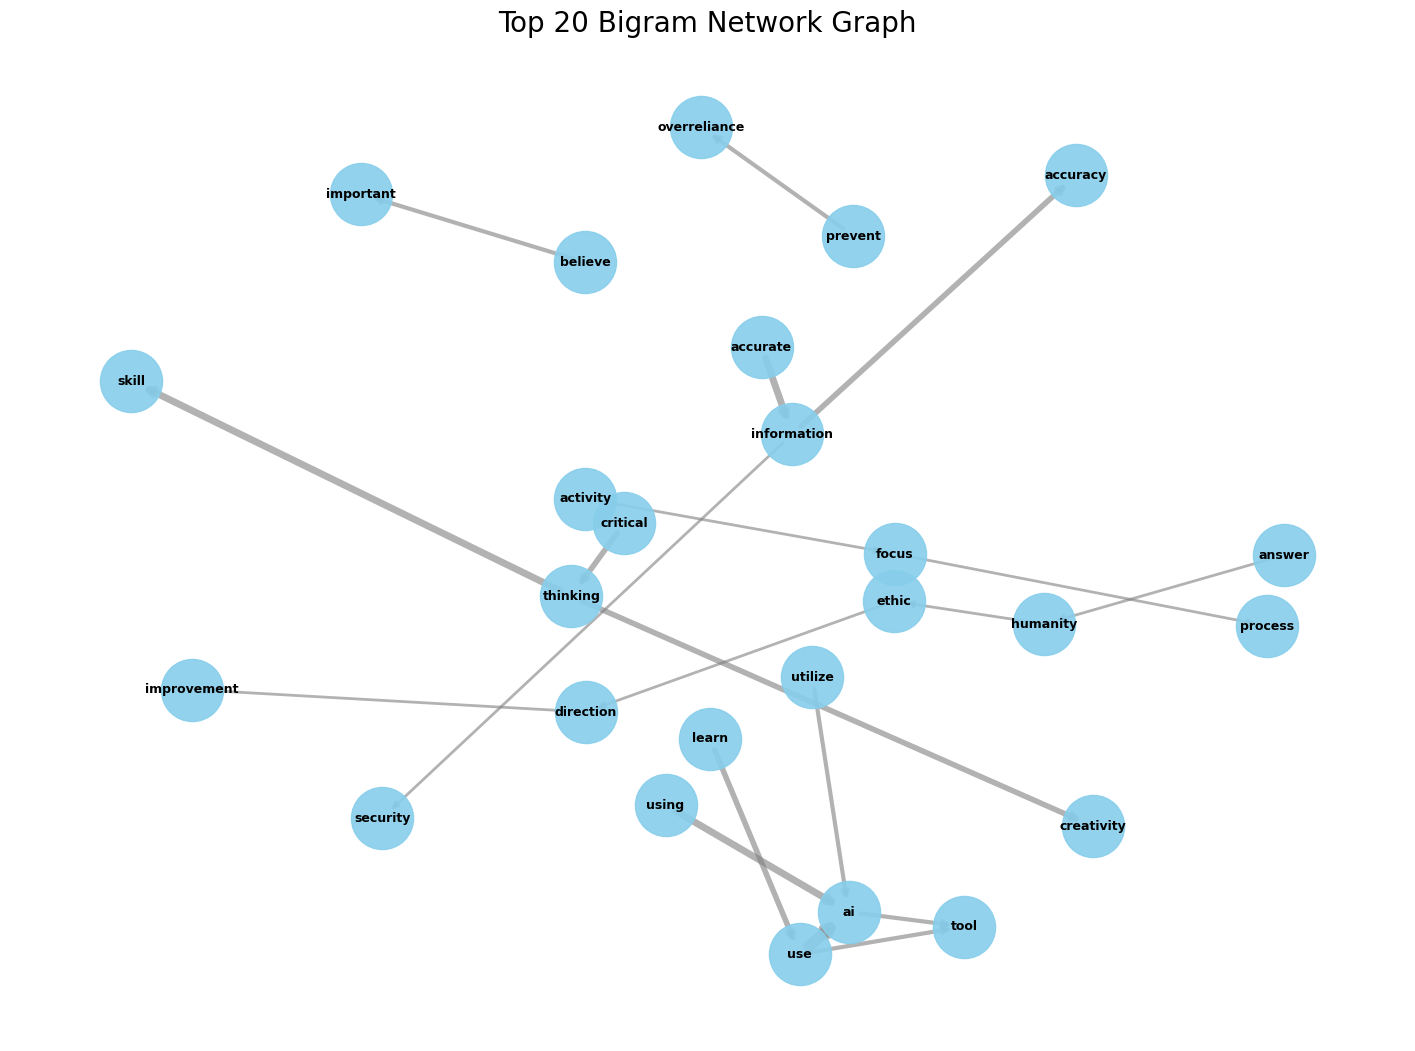

In [94]:
pos = nx.spring_layout(G, k=0.75, iterations=50) # k regulates the distance between nodes

plt.figure(figsize=(18, 13))

nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=2000, alpha=0.9)

edges = G.edges(data=True)
weights = [d['weight'] for u, v, d in edges]

nx.draw_networkx_edges(G, pos, width=weights, alpha=0.6, edge_color='gray')

nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

plt.title('Top 20 Bigram Network Graph', size=20)

plt.axis('off')

plt.show()

In [95]:
# bring sentiment wordnote
senti_word_net_path = '/content/drive/MyDrive/Colab Notebooks/SentiWordNet_3.0.0.txt'
senti_word_net = {}

with open(senti_word_net_path, 'r') as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith('#'):
            continue

        parts = line.split('\t')
        if len(parts) < 6:
            continue

        pos = parts[0]
        synset_id = parts[1]
        pos_score = float(parts[2])
        neg_score = float(parts[3])
        synset_terms_str = parts[4]

        synset_terms = synset_terms_str.split(' ')
        for term_entry in synset_terms:
            term = term_entry.split('#')[0].strip()
            if term:
                if term not in senti_word_net:
                    senti_word_net[term] = []
                senti_word_net[term].append({'PosScore': pos_score, 'NegScore': neg_score})

for item, values in senti_word_net.items():
    pos = -1234
    neg = -1234
    for score_dict in values:
        pos_val = score_dict.get('PosScore', 0)
        neg_val = score_dict.get('NegScore', 0)
        pos = max(pos, pos_val)
        neg = max(neg, neg_val)
    values = {'PosScore': pos, 'NegScore': neg}
    senti_word_net[item] = values

In [96]:
# Question 9
lemmatizer = WordNetLemmatizer()

benefit_texts = []

for text_entry in df['AI_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    benefit_texts.append(filtered_and_lemmatized_tokens)

In [97]:
# Question 9 sentiment result
benefit_sentiment = []

for text in benefit_texts:
  pos = 0
  neg = 0
  for word in text:
    if word in senti_word_net:
      pos += senti_word_net[word]['PosScore']
      neg += senti_word_net[word]['NegScore']
  benefit_sentiment.append(pos-neg)


df['AI_benefit_sentiment_score'] = benefit_sentiment
df['AI_benefit_sentiment'] = ['Positive' if score > 0 else 'Negative' for score in benefit_sentiment]

Text(0.5, 1.0, 'Distribution of Sentiment Scores')

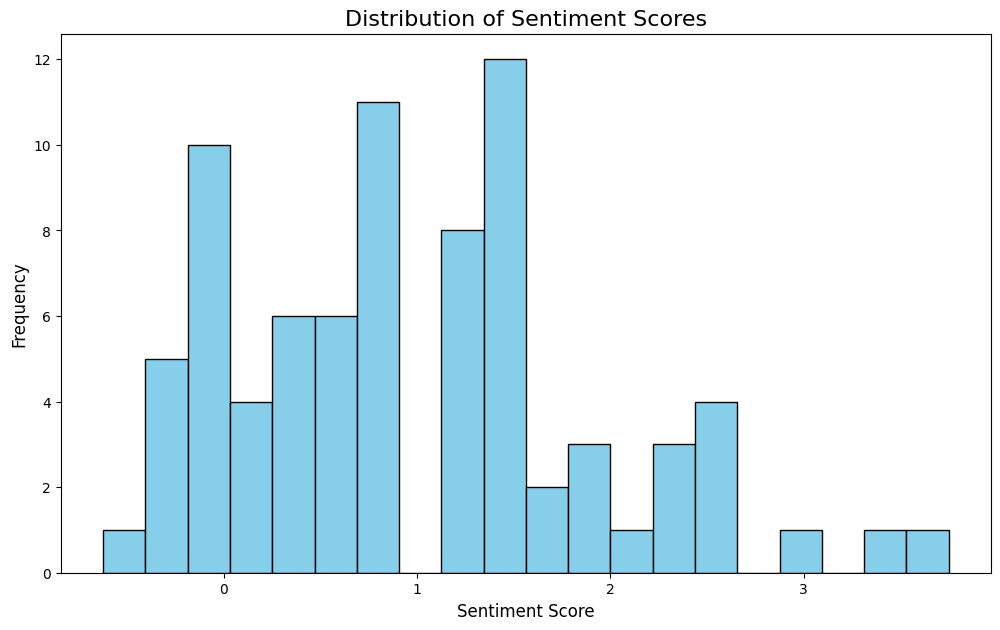

In [98]:
plt.figure(figsize=(12, 7))
plt.hist(df['AI_benefit_sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sentiment Scores', fontsize=16)

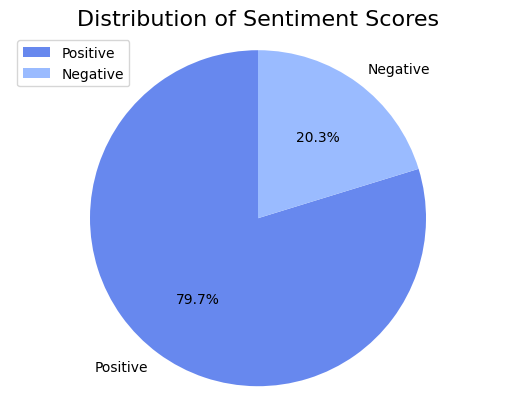

In [99]:
plt.pie(df['AI_benefit_sentiment'].value_counts(), labels=df['AI_benefit_sentiment'].value_counts().index, colors=sns.color_palette("coolwarm"), autopct='%1.1f%%', startangle=90)
plt.legend(labels=df['AI_benefit_sentiment'].value_counts().index)
plt.title('Distribution of Sentiment Scores', fontsize=16)
plt.axis('equal')
plt.show()

In [100]:
# Question 10 word tokenization
lemmatizer = WordNetLemmatizer()

future_education_texts = []

for text_entry in df['Important_education']:
    text_entry = str(text_entry).lower()

    tokens = word_tokenize(text_entry)

    filtered_and_lemmatized_tokens = [
        lemmatizer.lemmatize(word) for word in tokens
        if word.lower() not in stop_words and word.isalpha()
    ]

    future_education_texts.append(filtered_and_lemmatized_tokens)

In [101]:
# Question 10 sentiment result
future_education_sentiment = []

for text in future_education_texts:
  pos = 0
  neg = 0
  for word in text:
    if word in senti_word_net:
      pos += senti_word_net[word]['PosScore']
      neg += senti_word_net[word]['NegScore']
  future_education_sentiment.append(pos-neg)


df['AI_future_education_sentiment_score'] = future_education_sentiment
df['AI_future_education_sentiment'] = ['Positive' if score > 0 else 'Negative' for score in future_education_sentiment]

Text(0.5, 1.0, 'Distribution of Sentiment Scores')

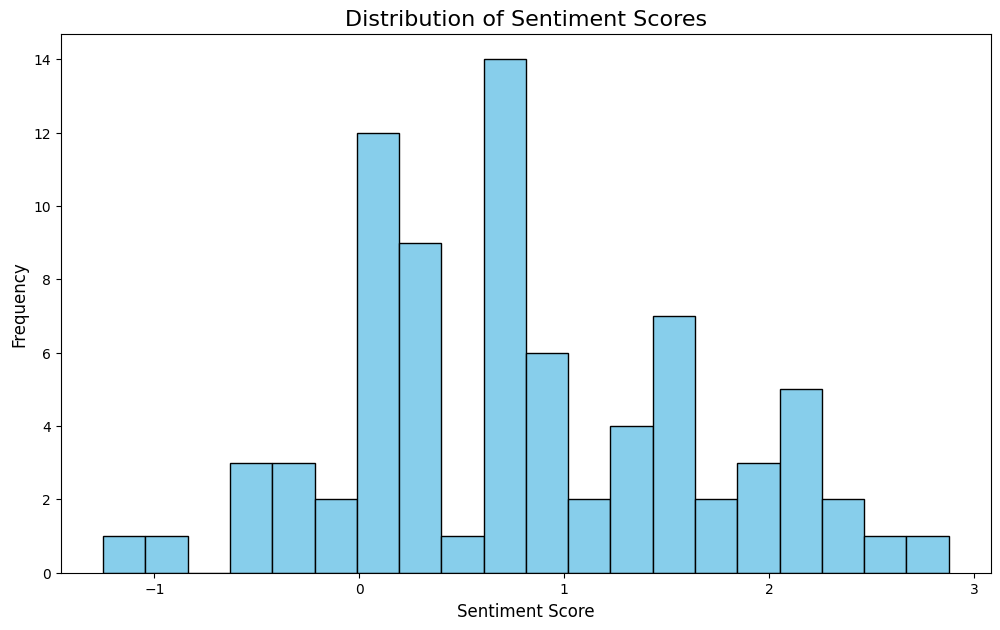

In [102]:
plt.figure(figsize=(12, 7))
plt.hist(df['AI_future_education_sentiment_score'], bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Sentiment Score', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Sentiment Scores', fontsize=16)

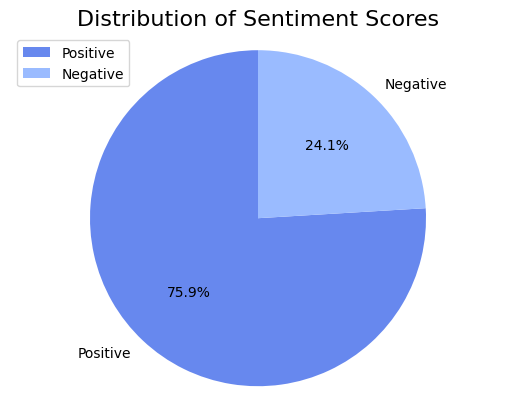

In [103]:
plt.pie(df['AI_future_education_sentiment'].value_counts(), labels=df['AI_future_education_sentiment'].value_counts().index, colors=sns.color_palette("coolwarm"), autopct='%1.1f%%', startangle=90)
plt.legend(labels=df['AI_future_education_sentiment'].value_counts().index)
plt.title('Distribution of Sentiment Scores', fontsize=16)
plt.axis('equal')
plt.show()

In [104]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer_education = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_vectorizer_important = TfidfVectorizer(
    max_df=0.95,
    min_df=2,
    ngram_range=(1, 2)
)

tfidf_education_matrix = tfidf_vectorizer_education.fit_transform(processed_education_texts)
tfidf_important_education_matrix = tfidf_vectorizer_important.fit_transform(processed_important_education_texts)

In [105]:
# Question 9 LDA Result
from sklearn.cluster import KMeans

num_clusters = 3

km = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
km.fit(tfidf_education_matrix)

cluster_labels = km.labels_

feature_names = tfidf_vectorizer_education.get_feature_names_out()

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [feature_names[ind] for ind in order_centroids[i, :10]]
    print("\t" + ", ".join(top_terms))

    print("\n\tSample documents:")
    sample_documents_indices = [idx for idx, label in enumerate(cluster_labels) if label == i]
    for doc_idx in sample_documents_indices[:3]:
        print(f"\t- {processed_education_texts[doc_idx]}")




Cluster 0:
	skill, nan, thinking, support, judgment, supplementary, human, capability, strengthening, question

	Sample documents:
	- regulation illegal information
	- literacy questioning skill
	- cultivating communication empathy skill society

Cluster 1:
	ai, education, utilization, human, believe, tool, learning, utilize ai, utilize, knowledge

	Sample documents:
	- ai may able replace knowledge believe human value humanity taught people
	- standardized numerical part accurate ai thought thinking part done human educating importance correct thinking
	- since world living without ai difficult soon arrive ai ignored need incorporated learning process extent however believe clear strict distinction student understanding ai using assignment

Cluster 2:
	learning, education, using ai, using, curriculum, ai, student, foster, creativity, character education

	Sample documents:
	- self driven learning
	- research new academic field advice learning process would helpful
	- education focus 

/tmp/ipykernel_718/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


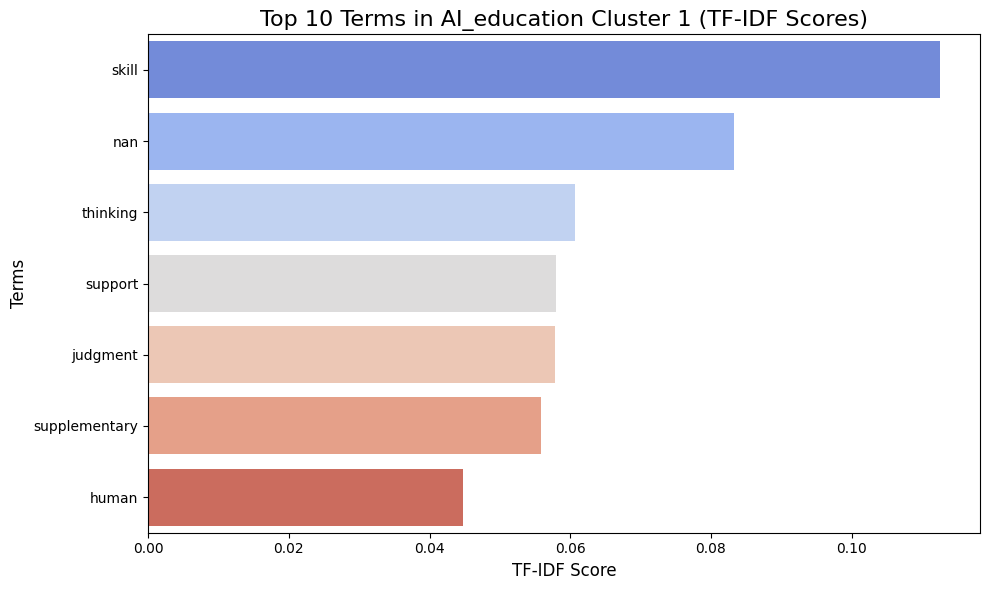

/tmp/ipykernel_718/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


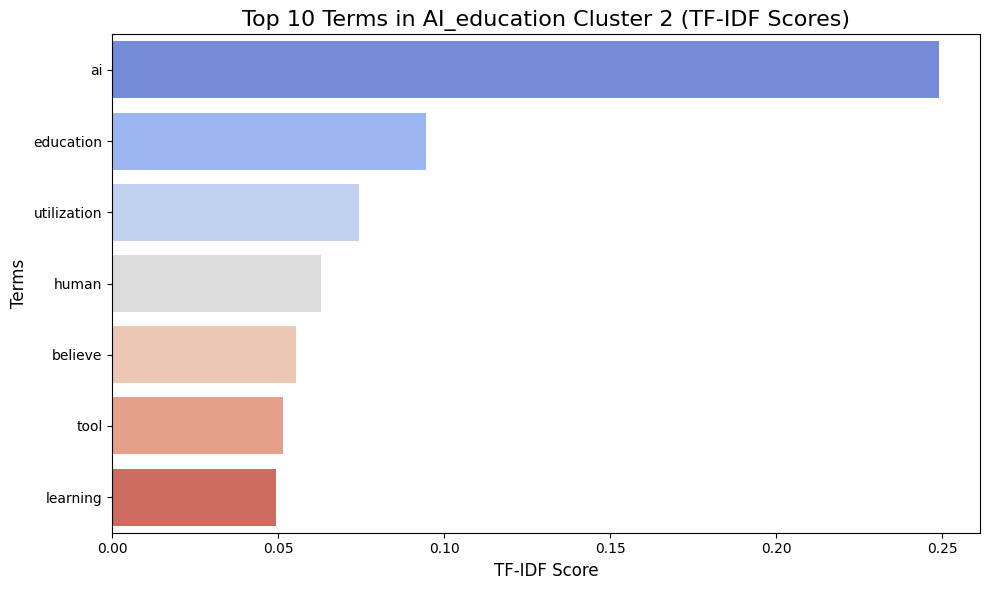

/tmp/ipykernel_718/3258925421.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


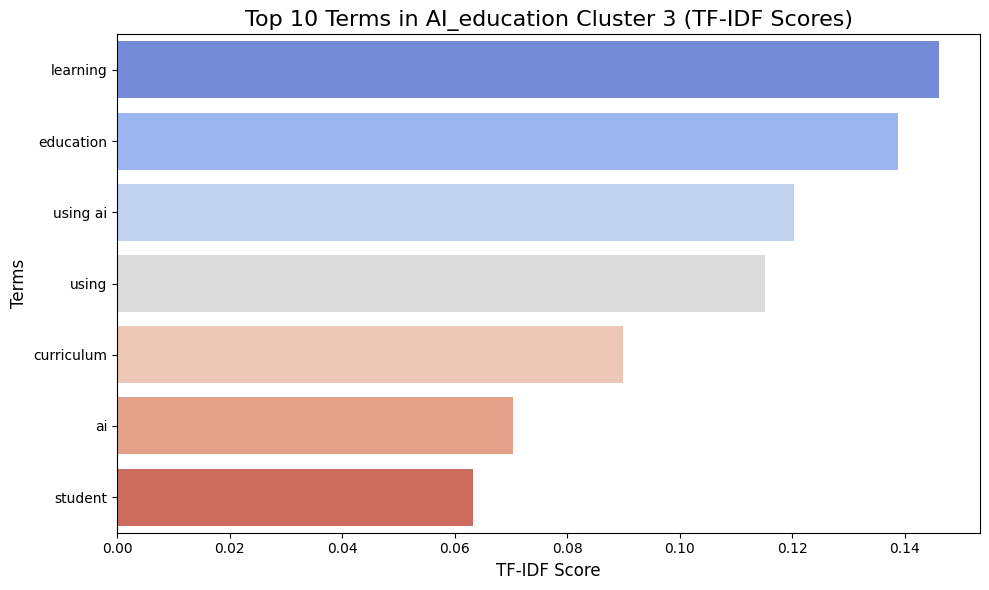

In [106]:
num_clusters_education = num_clusters
feature_names_education = feature_names
order_centroids_education = order_centroids

for i in range(num_clusters_education):
    top_term_indices = order_centroids_education[i, :7]

    top_terms = [feature_names_education[ind] for ind in top_term_indices]
    top_term_scores = km.cluster_centers_[i, top_term_indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')

    plt.title(f'Top 10 Terms in AI_education Cluster {i+1} (TF-IDF Scores)', fontsize=16)
    plt.xlabel('TF-IDF Score', fontsize=12)
    plt.ylabel('Terms', fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_718/2024161830.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_education.index, y=cluster_counts_education.values, palette="plasma")


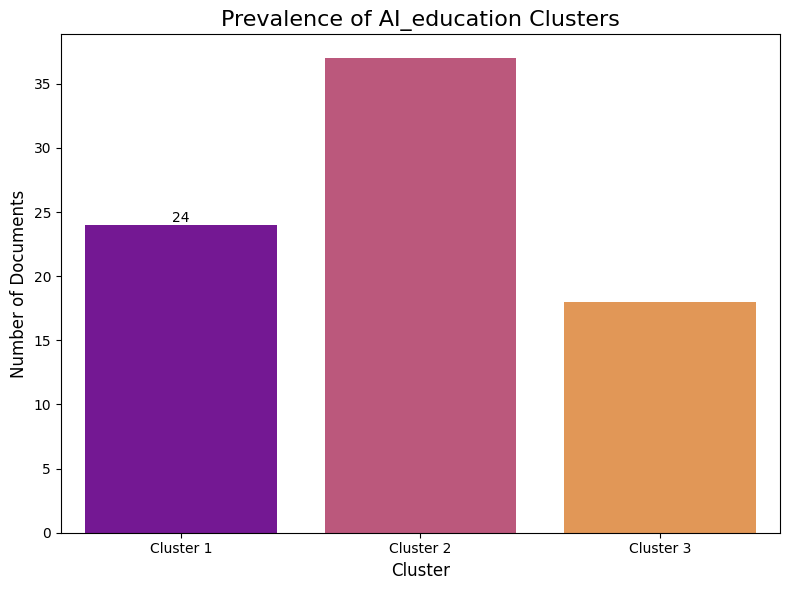

In [107]:
cluster_labels_education = km.labels_
cluster_counts_education = pd.Series(cluster_labels_education).value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=cluster_counts_education.index, y=cluster_counts_education.values, palette="plasma")
plt.title('Prevalence of AI_education Clusters', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(ticks=cluster_counts_education.index, labels=[f'Cluster {i+1}' for i in cluster_counts_education.index])
plt.bar_label(plt.gca().containers[0])
plt.tight_layout()
plt.show()

In [108]:
# Question 10 LDA Result
from sklearn.cluster import KMeans

num_clusters = 3

km = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
km.fit(tfidf_important_education_matrix)

cluster_labels = km.labels_

feature_names = tfidf_vectorizer_important.get_feature_names_out()

order_centroids = km.cluster_centers_.argsort()[:, ::-1]
for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [feature_names[ind] for ind in order_centroids[i, :10]]
    print("\t" + ", ".join(top_terms))

    print("\n\tSample documents:")
    sample_documents_indices = [idx for idx, label in enumerate(cluster_labels) if label == i]
    for doc_idx in sample_documents_indices[:3]:
        print(f"\t- {processed_important_education_texts[doc_idx]}")



Cluster 0:
	ai, use, must, education, thinking, one, tool, use ai, using ai, using

	Sample documents:
	- believe ai assist activity focus exploring process rather simply finding answer
	- humanity ethic
	- direction human education remains unchanged ai major tool improving education modern society necessary consult discus direction improvement member society

Cluster 1:
	information, accurate, accurate information, accuracy, learning, information accuracy, maintaining, ensure, dependence, providing

	Sample documents:
	- accurate learning information security
	- accurate information
	- accuracy information

Cluster 2:
	creativity, thinking, foster, answer, fostering, various, thinking creativity, education, independent thinking, independent

	Sample documents:
	- creativity originality
	- literacy creativity independent thinking skill
	- creativity


/tmp/ipykernel_718/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


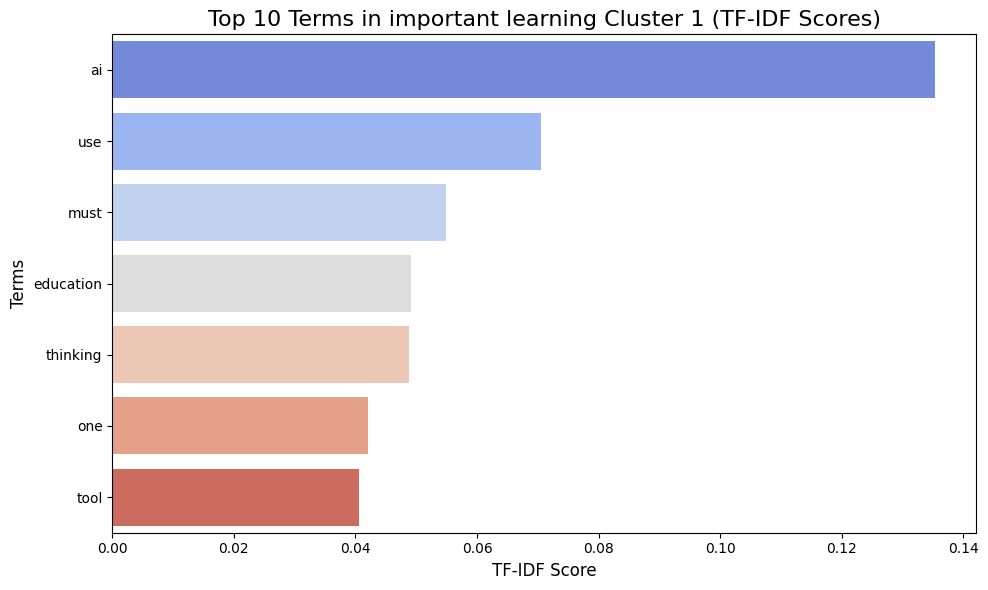

/tmp/ipykernel_718/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


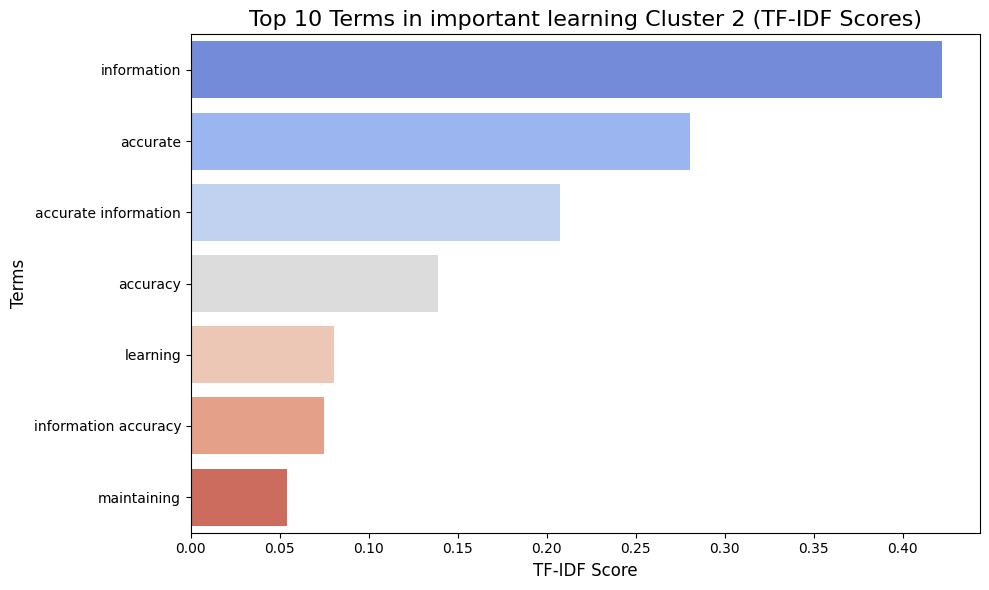

/tmp/ipykernel_718/698283257.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')


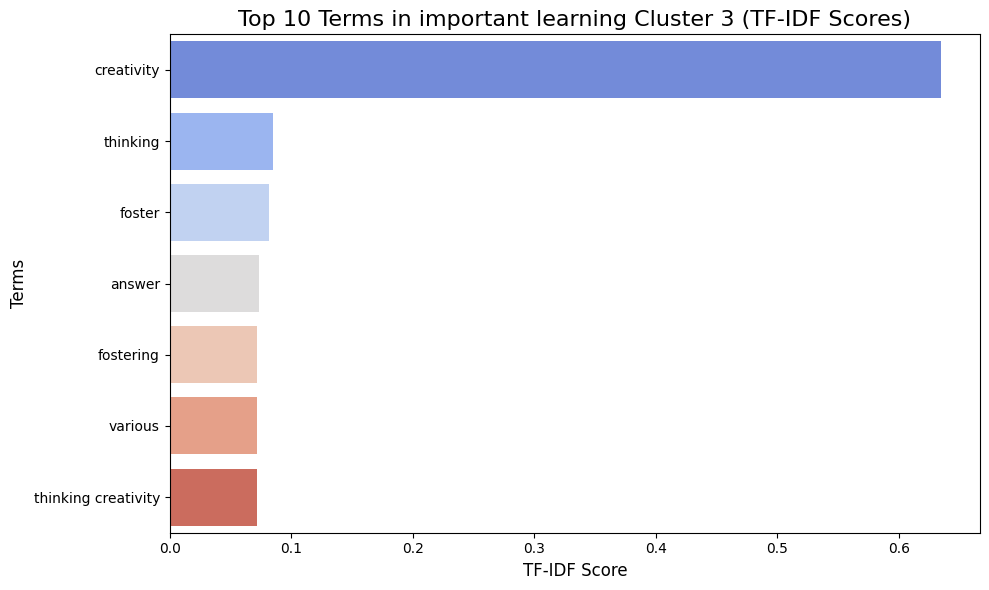

In [109]:
num_clusters_important_education = num_clusters
feature_names_important_education = feature_names
order_centroids_important_education = order_centroids

for i in range(num_clusters_important_education):
    top_term_indices = order_centroids_important_education[i, :7]

    top_terms = [feature_names_important_education[ind] for ind in top_term_indices]
    top_term_scores = km.cluster_centers_[i, top_term_indices]

    plt.figure(figsize=(10, 6))
    sns.barplot(x=top_term_scores, y=top_terms, palette='coolwarm')

    plt.title(f'Top 10 Terms in important learning Cluster {i+1} (TF-IDF Scores)', fontsize=16)
    plt.xlabel('TF-IDF Score', fontsize=12)
    plt.ylabel('Terms', fontsize=12)

    plt.tight_layout()
    plt.show()

/tmp/ipykernel_718/3731657012.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cluster_counts_important_education.index, y=cluster_counts_important_education.values, palette="plasma")


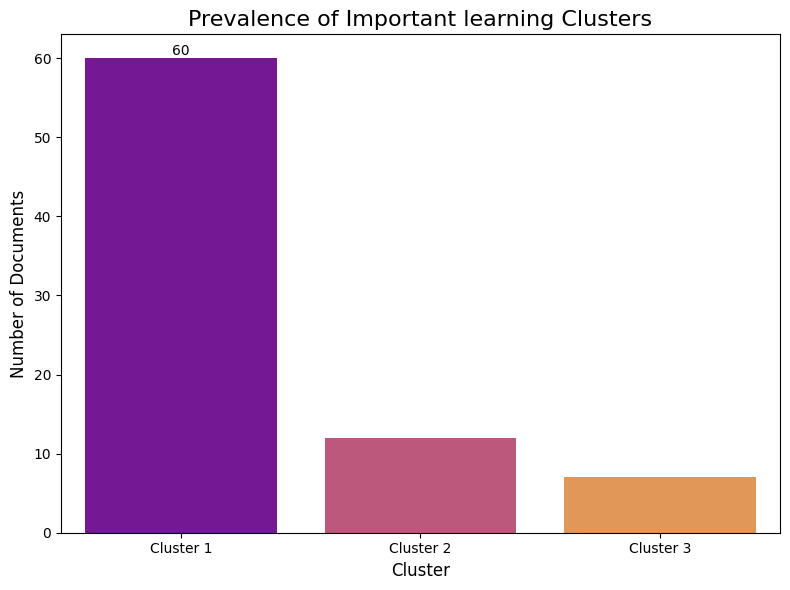

In [110]:
cluster_labels_important_education = km.labels_
cluster_counts_important_education = pd.Series(cluster_labels_important_education).value_counts().sort_index()

plt.figure(figsize=(8, 6))
sns.barplot(x=cluster_counts_important_education.index, y=cluster_counts_important_education.values, palette="plasma")
plt.title('Prevalence of Important learning Clusters', fontsize=16)
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Number of Documents', fontsize=12)
plt.xticks(ticks=cluster_counts_important_education.index, labels=[f'Cluster {i+1}' for i in cluster_counts_important_education.index])
plt.bar_label(plt.gca().containers[0])
plt.tight_layout()
plt.show()